In [ ]:
from google.colab import files


uploaded = files.upload()


Saving CI_SymbolPrice_2025-06-02T030821Z.csv to CI_SymbolPrice_2025-06-02T030821Z.csv
Saving CI_SymbolPrice_2025-06-02T030407Z.csv to CI_SymbolPrice_2025-06-02T030407Z.csv


In [ ]:
from google.colab import files


uploaded = files.upload()


Saving .env to .env


In [ ]:
!pip install python-dotenv


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving heards_structured_cleaned_v11.csv to heards_structured_cleaned_v11.csv


In [22]:
import pandas as pd
import numpy as np
import requests
import json
import os
import re
from dotenv import load_dotenv
from datetime import datetime

# ---------- Configuration ----------
load_dotenv()
DATA_FILE = "heards_structured_cleaned_v11.csv"
API_URL = "https://api.deepseek.com/v1/chat/completions"
API_KEY = os.getenv("SEEK_API_KEY")
N_SAMPLE = 400
RANDOM_STATE = 42
DATE_TOLERANCE_DAYS = 5
CHECKPOINT_RATIO = 0.05
# -----------------------------------


def parse_date_safe(date_str):
    try:
        return datetime.strptime(date_str, "%Y-%m-%d")
    except:
        return None


def validate_date(actual, predicted):
    actual_dt = parse_date_safe(actual)
    predicted_dt = parse_date_safe(predicted)
    if actual_dt and predicted_dt:
        return int(
            actual_dt.month == predicted_dt.month and abs(actual_dt.day - predicted_dt.day) <= DATE_TOLERANCE_DAYS
        )
    return 0


def call_deepseek(row):
    prompt = (
        "You are a data validator. Extract the best guess for each field. "
        "Return JSON with keys: start_date, end_date, action_type, party, price_basis. "
        "Each should be your best inferred value based on this row:\n\n"
        f"{row.to_dict()}"
    )

    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
    }

    payload = {
        "model": "deepseek-chat",
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0.2,
    }

    try:
        response = requests.post(API_URL, headers=headers, data=json.dumps(payload))
        response.raise_for_status()
        content = response.json()["choices"][0]["message"]["content"]

        match = re.search(r"```json\s*({.*?})\s*```", content, re.DOTALL)
        if match:
            return json.loads(match.group(1))
        return json.loads(content.strip())
    except Exception as e:
        print(f"[DeepSeek Error] Row {row.name}: {e}")
        return {}


def print_accuracy(validated, fields):
    print("\n--- Checkpoint Accuracy ---")
    for field in fields:
        accuracy = validated[field].mean() * 100
        print(f"{field.replace('_correct', '')}: {accuracy:.2f}%")
    print("----------------------------------")


def main():
    df = pd.read_csv(DATA_FILE).sample(n=N_SAMPLE, random_state=RANDOM_STATE).reset_index(drop=True)

    results = []
    fields = ["start_date_correct", "end_date_correct", "action_type_correct", "party_correct", "price_basis_correct"]
    checkpoint = int(N_SAMPLE * CHECKPOINT_RATIO)

    for idx, row in df.iterrows():
        prediction = call_deepseek(row)

        validated_row = {
            "start_date_correct": validate_date(row["start_date"], prediction.get("start_date", "")),
            "end_date_correct": validate_date(row["end_date"], prediction.get("end_date", "")),
            "action_type_correct": int(str(row["action_type"]).lower() == str(prediction.get("action_type", "")).lower()),
            "party_correct": int(str(row["party"]).lower() == str(prediction.get("party", "")).lower()),
            "price_basis_correct": int(str(row["price_basis"]).lower() in str(prediction.get("price_basis", "")).lower()),
        }

        results.append(validated_row)

        if (idx + 1) % checkpoint == 0 or (idx + 1) == N_SAMPLE:
            checkpoint_df = pd.DataFrame(results)
            print(f"\nProgress: {idx + 1}/{N_SAMPLE} rows checked.")
            print_accuracy(checkpoint_df, fields)

if __name__ == "__main__":
    main()



Progress: 20/400 rows checked.

--- Checkpoint Accuracy ---
start_date: 100.00%
end_date: 95.00%
action_type: 100.00%
party: 100.00%
price_basis: 100.00%
----------------------------------

Progress: 40/400 rows checked.

--- Checkpoint Accuracy ---
start_date: 100.00%
end_date: 97.50%
action_type: 100.00%
party: 100.00%
price_basis: 100.00%
----------------------------------

Progress: 60/400 rows checked.

--- Checkpoint Accuracy ---
start_date: 100.00%
end_date: 98.33%
action_type: 100.00%
party: 100.00%
price_basis: 100.00%
----------------------------------

Progress: 80/400 rows checked.

--- Checkpoint Accuracy ---
start_date: 100.00%
end_date: 98.75%
action_type: 100.00%
party: 100.00%
price_basis: 100.00%
----------------------------------

Progress: 100/400 rows checked.

--- Checkpoint Accuracy ---
start_date: 100.00%
end_date: 99.00%
action_type: 100.00%
party: 100.00%
price_basis: 100.00%
----------------------------------

Progress: 120/400 rows checked.

--- Checkpoint 

KeyboardInterrupt: 

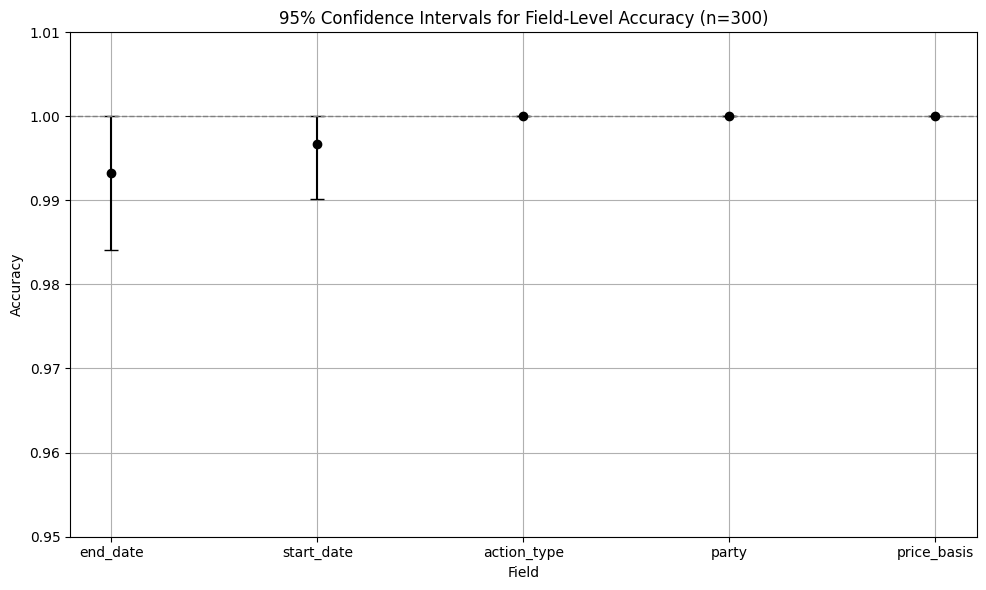

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Sample size
n = 300
z = norm.ppf(0.975)  # z-score for 95% confidence

# Accuracy results from your checkpoint
accuracies = {
    'start_date': 0.9967,
    'end_date': 0.9933,
    'action_type': 1.0,
    'party': 1.0,
    'price_basis': 1.0,
}

# Calculate confidence intervals
ci_data = {}
for field, acc in accuracies.items():
    se = np.sqrt(acc * (1 - acc) / n)
    ci_lower = max(0, acc - z * se)
    ci_upper = min(1, acc + z * se)
    ci_data[field] = (acc, ci_lower, ci_upper)

# Convert to DataFrame
ci_df = pd.DataFrame.from_dict(ci_data, orient='index', columns=['accuracy', 'lower', 'upper'])
ci_df = ci_df.sort_values('accuracy', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.errorbar(ci_df.index, ci_df['accuracy'],
             yerr=[ci_df['accuracy'] - ci_df['lower'], ci_df['upper'] - ci_df['accuracy']],
             fmt='o', capsize=5, color='black')

plt.ylim(0.95, 1.01)
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1)
plt.title("95% Confidence Intervals for Field-Level Accuracy (n=300)")
plt.ylabel("Accuracy")
plt.xlabel("Field")
plt.grid(True)
plt.tight_layout()
plt.show()
